In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
from sklearn.inspection import partial_dependence
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay


In [26]:
prices = pd.read_csv('delhi_prices.csv')
info = pd.read_csv('delhi_information.csv')

# Merge
df = pd.merge(prices, info, on='Flight ID')
# Basic informations
print("Size of dataset:", df.shape)
print("\nFirst 5 lines of data:")
print(df.head(5))


Size of dataset: (82481, 16)

First 5 lines of data:
   Flight ID Journey Date_x  Days Before Journey Date  Fare (Rupees)  \
0          1     06/03/2023                        50           9840   
1          2     06/03/2023                        50           9840   
2          3     16/01/2023                         1          11625   
3          4     23/01/2023                         8           9909   
4          5     30/01/2023                        15           8895   

   Fare (GBP) Journey Date_y Journey Day    Airline Flight Number    Class  \
0       98.40     06/03/2023      Monday    Vistara        UK-927  Economy   
1       98.40     06/03/2023      Monday    Vistara        UK-963  Economy   
2      116.25     16/01/2023      Monday  Air India        AI-885  Economy   
3       99.09     23/01/2023      Monday  Air India        AI-560  Economy   
4       88.95     30/01/2023      Monday  Air India        AI-542  Economy   

  Origin     Departure  Number Of Stops      

In [27]:
# Data cleaning
print("\nMissing value detection:")
print(df.isnull().sum())

print(df[['Fare (Rupees)', 'Airline', 'Days Before Journey Date']].describe())


Missing value detection:
Flight ID                   0
Journey Date_x              0
Days Before Journey Date    0
Fare (Rupees)               0
Fare (GBP)                  0
Journey Date_y              0
Journey Day                 0
Airline                     0
Flight Number               0
Class                       0
Origin                      0
Departure                   0
Number Of Stops             0
Arrival                     0
Destination                 0
Duration (Hours)            0
dtype: int64
       Fare (Rupees)  Days Before Journey Date
count   82481.000000              82481.000000
mean    20539.703483                 25.757423
std     18218.125648                 14.350843
min      2343.000000                  1.000000
25%      8234.000000                 13.000000
50%     11856.000000                 26.000000
75%     30249.000000                 38.000000
max    123260.000000                 50.000000


## Identify fare anomalies
### Find those tickets that are “overly expensive” or “overly cheap”

In [28]:
# Grouped by route (to prevent prices for Delhi–Mumbai and Delhi–Bangalore from being compared together)
df['Route'] = df['Origin'] + ' to ' + df['Destination']

# Identifying fare anomalies using the IQR method
def detect_outliers(group):
    Q1 = group['Fare (Rupees)'].quantile(0.25)
    Q3 = group['Fare (Rupees)'].quantile(0.75)
    IQR = Q3 - Q1

    # Anomaly borders
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 3.0 * IQR  # For Business class ticket
    

    # Label anomalies
    group['Is_Outlier'] = (
        (group['Fare (Rupees)'] < lower_bound) |
        (group['Fare (Rupees)'] > upper_bound)
    )

    # Low price anomalies and High price anomalies
    group['Is_Cheap_Outlier'] = group['Fare (Rupees)'] < lower_bound
    group['Is_Expensive_Outlier'] = group['Fare (Rupees)'] > upper_bound

    return group


df_with_outliers = df.groupby('Route').apply(detect_outliers)

# High price anomalies
expensive_anomalies = df_with_outliers[
    df_with_outliers['Is_Expensive_Outlier'] 
]

print("🔥 Abnormally high prices (possibly due to business class, pricing errors, or special requests):")
print(expensive_anomalies[
    ['Flight ID', 'Route', 'Fare (Rupees)', 'Days Before Journey Date', 'Airline']
])

# 5. Low price anomalies
cheap_anomalies = df_with_outliers[
    df_with_outliers['Is_Cheap_Outlier']
]

print("\n❄️ Abnormally low prices (possibly due to promotions, data errors, or missing taxes):")
print(cheap_anomalies[
    ['Flight ID', 'Route', 'Fare (Rupees)', 'Days Before Journey Date', 'Airline']
])

🔥 Abnormally high prices (possibly due to business class, pricing errors, or special requests):
                          Flight ID               Route  Fare (Rupees)  \
Route                                                                    
Delhi to Hyderabad 2217        2218  Delhi to Hyderabad          75710   
                   2218        2219  Delhi to Hyderabad          75710   
                   21734      21597  Delhi to Hyderabad          77972   
                   21738      21601  Delhi to Hyderabad          77972   
                   21754      21617  Delhi to Hyderabad          74086   
...                             ...                 ...            ...   
Delhi to Mumbai    79928      79426     Delhi to Mumbai          96223   
                   80238      79736     Delhi to Mumbai          89598   
                   80256      79754     Delhi to Mumbai          95097   
                   80567      80065     Delhi to Mumbai          88366   
                

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\2887221762.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_with_outliers = df.groupby('Route').apply(detect_outliers)


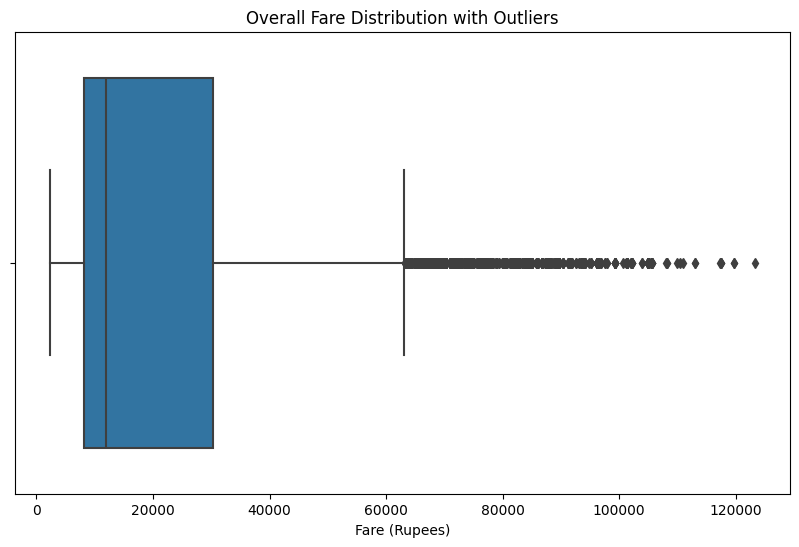

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Fare (Rupees)'])

plt.title('Overall Fare Distribution with Outliers')
plt.xlabel('Fare (Rupees)')
plt.show()

### Interpretation of the Boxplot

This boxplot illustrates a highly right-skewed distribution of flight fares from Delhi, along with a clear price stratification pattern.

### Central Tendency

The box and median line are concentrated in the lower price range, indicating that most flight fares (approximately 50%) fall within relatively low price levels.
The median fare is around 12,000 INR, while the upper quartile reaches approximately 28,000 INR.

### Price Stratification

A long upper whisker extends from the box, followed by a large number of scattered high-value points.
This indicates the presence of many expensive flights above 60,000 INR, with some fares reaching up to 120,000 INR, forming a distinct high-end pricing segment.

### Distribution Shape

The long right tail and dense high-value outliers together form a typical right-skewed distribution.
This suggests that while high-priced flights are relatively rare, they exhibit a very large price range, clearly separated from the main low-cost market.

### Conclusion

The dataset shows strong evidence of price stratification.
Most flights are concentrated in the low-price segment, while a smaller but significant high-end market exists with extremely high fare variability.

This reflects a high degree of heterogeneity in airline pricing behavior, where premium pricing can reach substantially higher levels than the mainstream market.

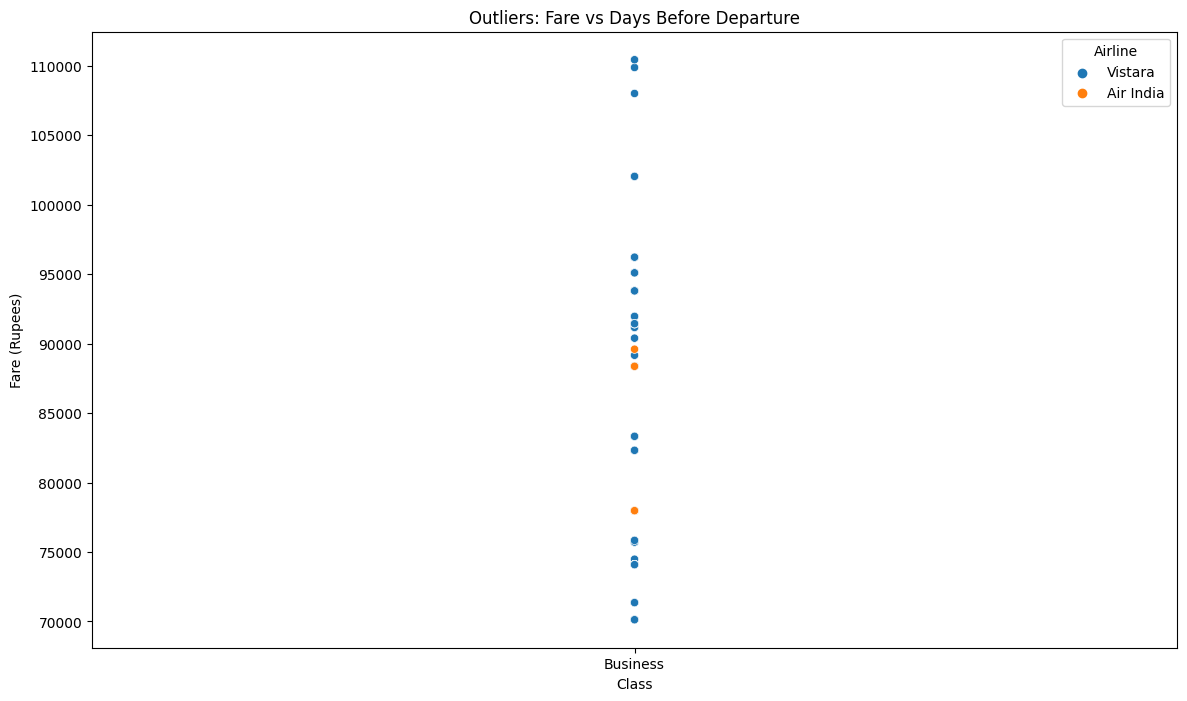

In [24]:
outliers = df_with_outliers[df_with_outliers['Is_Outlier']]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=outliers,
    x='Class',
    y='Fare (Rupees)',
    hue='Airline'
)

plt.title('Outliers: Fare vs Days Before Departure')
plt.show()

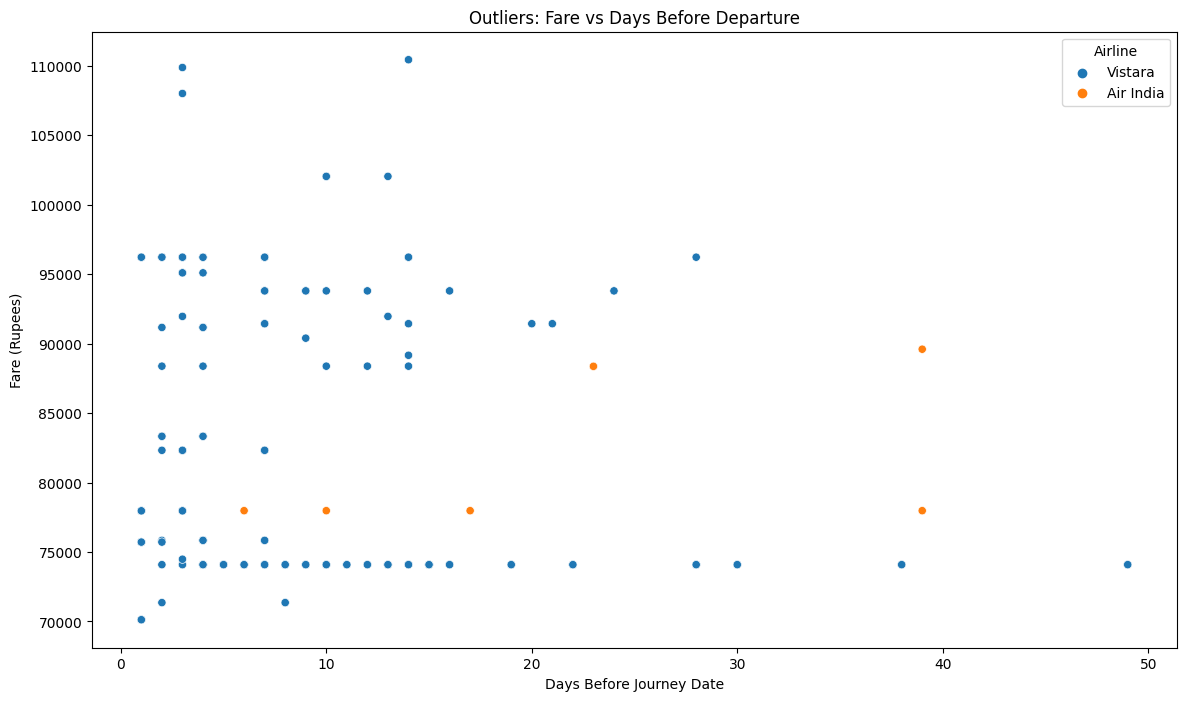

In [30]:
outliers = df_with_outliers[df_with_outliers['Is_Outlier']]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=outliers,
    x='Days Before Journey Date',
    y='Fare (Rupees)',
    hue='Airline'
)

plt.title('Outliers: Fare vs Days Before Departure')
plt.show()

## 📊 Interpretation of the Outlier Scatter Plot

This scatter plot shows flight data identified as **outliers** by the model, analyzing the relationship between **fare (price)** and **days before departure**, while distinguishing between different airlines.

  - 🔵 Blue points: Vistara Airlines  
  - 🟠 Orange points: Air India  

---

### 🔍 Key Observations

### ✈️ Vistara dominates the outliers
Most of the detected outliers belong to **Vistara Airlines**, forming a dense cluster in the high-price region.  
This suggests either:
- Frequent high-priced pricing behavior, or  
- Potential anomalies or data inconsistencies in Vistara records.

---

### ✈️ Air India appears less frequently
Air India has only a small number of outlier points, mainly distributed between **10–40 days before departure**.  
This indicates:
- Fewer extreme pricing events, or  
- More stable pricing behavior compared to Vistara.

---

### 💰 Fare distribution characteristics
- Most outliers are concentrated in the **75,000–90,000 INR range**, forming a baseline high-price band.  
- A smaller number of extreme points reach **100,000–110,000 INR**, potentially representing ultra-premium fares or data errors.

---

### ⏱️ Time-related patterns
- Outliers are spread across the entire time range (1 to 50 days before departure).  
- There is no clear pattern such as:
  - “earlier booking = cheaper price”
  - or “last-minute booking = higher price”

This suggests that these anomalies are likely driven by factors other than time, such as:
- seat class (business/first class)
- promotional pricing errors
- demand shocks or special events

---

## 🧠 Potential Insights

### ✈️ Vistara pricing behavior
Vistara shows frequent occurrences of high-value outliers, which may indicate:
- aggressive dynamic pricing strategies, or  
- inconsistencies in fare recording (e.g., misplaced zeros or data entry issues)

---

### ✈️ Air India stability
Air India exhibits fewer extreme values, suggesting:
- more stable pricing behavior in the high-fare segment, or  
- fewer premium-class observations in the dataset

---

### 📉 Lack of temporal structure
The absence of a clear time-based trend implies that:
- these outliers are not primarily driven by booking time  
- other factors (seat class, demand spikes, events) are likely more influential

---

## 📌 Recommendations

- 🔎 Manually verify Vistara fares above **100,000 INR** to detect possible data entry errors  
- 📊 Further analyze Air India’s mid-range outliers (10–40 days) for potential pricing patterns  
- 🧩 Incorporate additional features such as:
  - cabin class  
  - holiday/season indicators  
  - flight time and demand conditions  

---

## 🧾 Summary

This plot reveals that **Vistara Airlines dominates the high-fare outlier space**, while **Air India appears more stable and less volatile**.  
The lack of a clear time-related trend suggests that these anomalies are likely influenced by multiple complex factors beyond booking time alone.

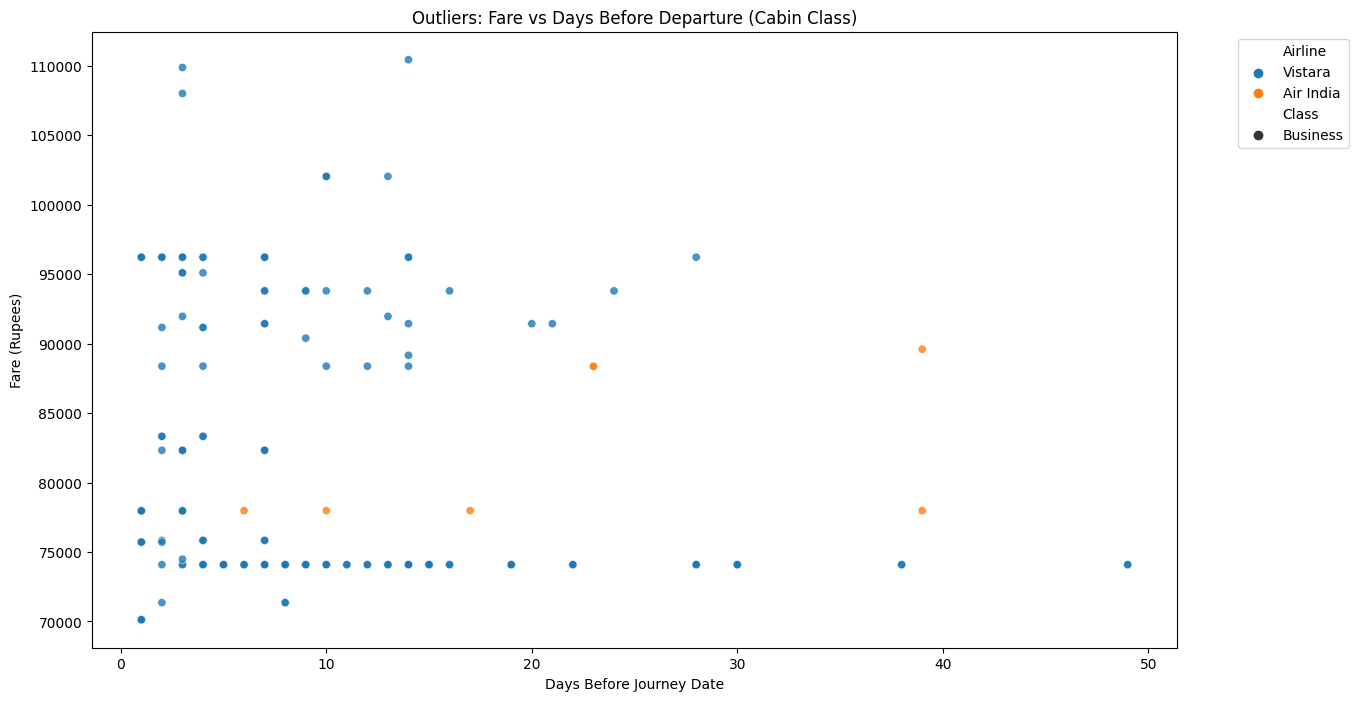

In [33]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=outliers,
    x='Days Before Journey Date',
    y='Fare (Rupees)',
    hue='Airline',
    style='Class',   # ⭐ 用形状区分舱位
    alpha=0.8
)

plt.title('Outliers: Fare vs Days Before Departure (Cabin Class)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## XGB overall

In [14]:
# 特征工程：构建对模型更有用的特征
# 标记“最后一刻”购票 (小于7天)
df['Is_Last_Minute'] = (df['Days Before Journey Date'] < 7).astype(int)
# 标记“早鸟”购票 (大于45天)
df['Is_Early_Bird'] = (df['Days Before Journey Date'] > 45).astype(int)

# 准备特征矩阵
# 我们选择数值型和类别型特征
feature_cols = [
    'Days Before Journey Date',
    'Airline',
    'Destination',
    'Is_Last_Minute',
    'Is_Early_Bird',
    'Number Of Stops',
    'Duration (Hours)'
]

# One-Hot 编码 (处理类别特征)
X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['Fare (Rupees)']

# ==========================================
# 2. 模型训练
# ==========================================
print("正在训练 XGBoost 模型...")
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化并训练模型
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42,
    verbosity=0 # 关闭训练过程中的日志输出
)
model.fit(X_train, y_train)

print("模型训练完成！\n")

# --- 3. 异常检测 (基于残差) ---
y_pred = model.predict(X_test)
residuals = y_test - y_pred
df_test = X_test.copy()
df_test['Actual_Price'] = y_test
df_test['Predicted_Price'] = y_pred
df_test['Residual'] = residuals

# 找出异常值：预测误差最大的前 5%
threshold = np.percentile(np.abs(residuals), 95)
anomalies = df_test[np.abs(df_test['Residual']) > threshold]

print(f"\n发现 {len(anomalies)} 个异常样本 (误差最大的前5%)")
print(anomalies[['Actual_Price', 'Predicted_Price', 'Residual']].head())



正在训练 XGBoost 模型...
模型训练完成！


发现 825 个异常样本 (误差最大的前5%)
       Actual_Price  Predicted_Price      Residual
80172         87918     37710.500000  50207.500000
52850         61833     25554.654297  36278.345703
31393         76494     28149.876953  48344.123047
2188          74170     32073.066406  42096.933594
30757         58753     24069.482422  34683.517578


In [15]:
# 注意：因为我们在上面的代码中用了 train_test_split，索引是打乱的。
# 为了演示，我们这里直接针对全量数据做一个简化的异常筛选逻辑
# 或者，如果你能保存上面的 anomalies 索引最好。
# 这里我们直接用“价格极高”作为筛选标准，因为模型预测值都在3万左右，超过5万肯定是异常。

# 设定阈值：价格超过 50,000 卢比的样本
price_threshold = 50000
suspects = df[df['Fare (Rupees)'] > price_threshold].copy()

# --- 3. 侦探分析报告 ---
print(f"=== 异常样本总数: {len(suspects)} ===\n")

if len(suspects) > 0:
    # 我们只看前 10 个最贵的
    top_suspects = suspects.sort_values('Fare (Rupees)', ascending=False).head(10)
    
    # 打印关键列
    cols_to_show = ['Flight ID', 'Airline', 'Destination', 'Fare (Rupees)', 
                    'Days Before Journey Date', 'Class', 'Departure', 'Arrival']
    
    print("🔍 最贵的 10 个异常航班详情：")
    print(top_suspects[cols_to_show].to_string(index=False))
    
    # --- 4. 深度归因分析 ---
    print("\n--- 📊 异常特征统计 ---")
    
    # 1. 这些天价票都是哪家航空公司的？
    print("\n航空公司分布:")
    print(suspects['Airline'].value_counts())
    
    # 2. 都是飞往哪里的？
    print("\n目的地分布:")
    print(suspects['Destination'].value_counts())
    
    # 3. 都是提前多久买的？
    print(f"\n提前预订天数均值: {suspects['Days Before Journey Date'].mean():.1f} 天")
    print(f"提前预订天数中位数: {suspects['Days Before Journey Date'].median():.1f} 天")
    
    # 4. 舱位检查 (关键点！)
    if 'Class' in suspects.columns:
        print("\n舱位等级分布:")
        print(suspects['Class'].value_counts())
    else:
        print("\n⚠️ 警告: 数据集中缺少 'Class' 列，这可能是价格差异的关键隐藏特征！")

else:
    print("没有发现超过 50,000 卢比的票价，请检查数据或阈值。")

=== 异常样本总数: 8294 ===

🔍 最贵的 10 个异常航班详情：
 Flight ID Airline Destination  Fare (Rupees)  Days Before Journey Date    Class    Departure      Arrival
     22753 Vistara     Kolkata         123260                         6 Business  Before 6 AM 12 PM - 6 PM
     81187 Vistara     Chennai         119743                        28 Business 12 PM - 6 PM   After 6 PM
     22492 Vistara     Chennai         119743                         7 Business 12 PM - 6 PM   After 6 PM
     78939 Vistara     Kolkata         117486                         6 Business 12 PM - 6 PM   After 6 PM
     48896 Vistara     Kolkata         117486                         1 Business 6 AM - 12 PM   After 6 PM
     38506 Vistara     Kolkata         117486                         1 Business 12 PM - 6 PM   After 6 PM
     81252 Vistara     Chennai         117318                        24 Business 12 PM - 6 PM   After 6 PM
     48897 Vistara     Kolkata         113006                         1 Business 6 AM - 12 PM   After 6 

正在生成特征重要性图表...


<Figure size 1200x800 with 0 Axes>

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24615 (\

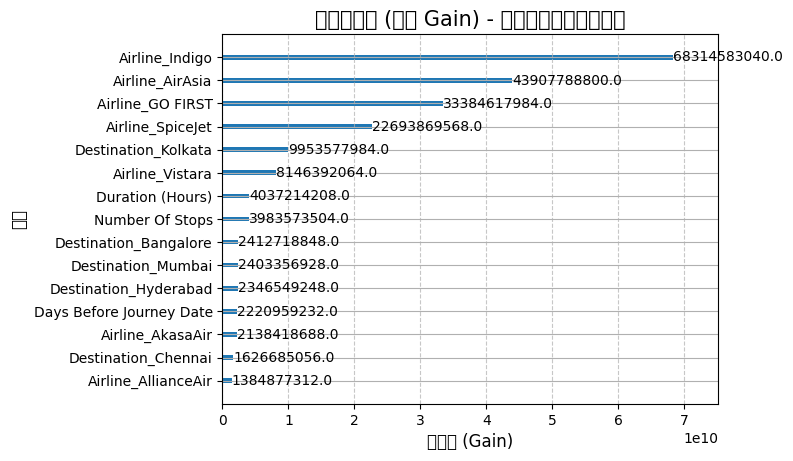

In [16]:
# --- 4. 解释模型 (替代 SHAP 的方案) ---

# 方案 A: 全局特征重要性
print("正在生成特征重要性图表...")
plt.figure(figsize=(12, 8))
# 使用 'gain' 指标，它代表了特征在分裂时带来的平均信息增益
xgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('特征重要性 (基于 Gain) - 哪些因素最影响票价？', fontsize=15)
plt.xlabel('重要性 (Gain)', fontsize=12)
plt.ylabel('特征', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()




C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 35746 (\N{CJK UNIFIED IDEOGRAPH-8BA2}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3904281122.py:34: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from cur

<Figure size 1200x600 with 0 Axes>

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31080 (\

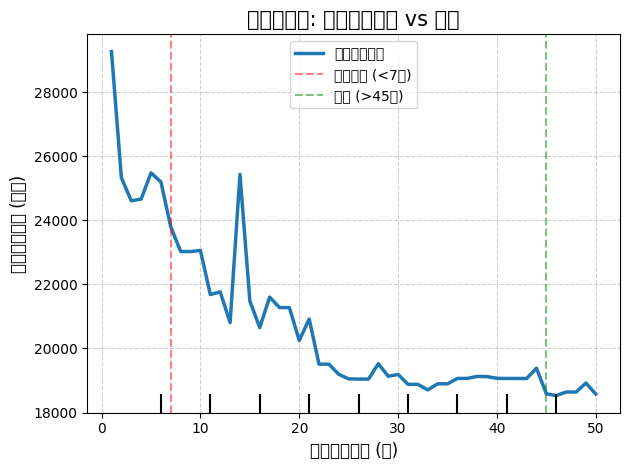

图表绘制完成！


In [20]:
# 方案 B: 局部解释 - 部分依赖图 (PDP)
# 我们想看 "提前预订天数" 对价格的具体影响曲线
# ==========================================
# 4. 局部解释：部分依赖图 (PDP) - 终极修正版
# ==========================================
# ==========================================
# 部分依赖图 (PDP) - 自动绘图纯净版
# ==========================================

# 1. 准备数据 (确保是浮点数以避免警告)
X_train_float = X_train.copy()
X_train_float['Days Before Journey Date'] = X_train_float['Days Before Journey Date'].astype(float)

# 2. 绘图
plt.figure(figsize=(12, 6))

# 直接让 sklearn 处理绘图逻辑
PartialDependenceDisplay.from_estimator(
    model, 
    X_train_float, 
    ['Days Before Journey Date'], 
    kind='average',
    line_kw={'label': '预测票价趋势', 'color': '#1f77b4', 'linewidth': 2.5}
)

# 3. 美化图表
plt.title('部分依赖图: 提前预订天数 vs 票价', fontsize=15)
plt.xlabel('提前预订天数 (天)', fontsize=12)
plt.ylabel('预测平均票价 (卢比)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='最后一刻 (<7天)')
plt.axvline(x=45, color='green', linestyle='--', alpha=0.5, label='早鸟 (>45天)')
plt.legend()
plt.tight_layout()
plt.show()

print("图表绘制完成！")


In [21]:
# 方案 C: 分析特定异常样本
# 选取一个具体的异常样本进行人工解释
if len(anomalies) > 0:
    sample_idx = anomalies.index[0]
    sample = anomalies.loc[sample_idx]
    
    print("\n=== 异常样本深度分析 ===")
    print(f"航班 ID: {df.loc[sample_idx, 'Flight ID']}")
    print(f"航空公司: {df.loc[sample_idx, 'Airline']}")
    print(f"目的地: {df.loc[sample_idx, 'Destination']}")
    print(f"实际价格: ₹{sample['Actual_Price']}")
    print(f"模型预测: ₹{sample['Predicted_Price']}")
    print(f"误差: ₹{sample['Residual']}")
    
    # 简单的逻辑解释
    if sample['Residual'] > 0:
        print("分析: 模型低估了价格。这可能是因为该航班属于'最后一刻'的高价票，或者该航空公司在该特定日期的溢价未被模型捕捉。")
    else:
        print("分析: 模型高估了价格。这可能是因为该航班有特殊的促销折扣，或者模型过度拟合了某些高价特征。")


=== 异常样本深度分析 ===
航班 ID: 79670
航空公司: Vistara
目的地: Kolkata
实际价格: ₹87918
模型预测: ₹37710.5
误差: ₹50207.5
分析: 模型低估了价格。这可能是因为该航班属于'最后一刻'的高价票，或者该航空公司在该特定日期的溢价未被模型捕捉。


In [22]:
# ==========================================
# 5. 异常检测与归因分析
# ==========================================
print("正在进行异常检测...")
# 在测试集上进行预测
y_pred = model.predict(X_test)
# 计算残差 (实际价格 - 预测价格)
residuals = y_test - y_pred

# 将结果整合到一个 DataFrame 中方便查看
df_test_results = X_test.copy()
df_test_results['Actual_Price'] = y_test
df_test_results['Predicted_Price'] = y_pred
df_test_results['Residual'] = residuals
df_test_results['Abs_Residual'] = np.abs(residuals)

# 找出“异常值”：残差绝对值最大的前 5%
threshold = np.percentile(df_test_results['Abs_Residual'], 95)
anomalies = df_test_results[df_test_results['Abs_Residual'] > threshold]

print(f"检测完成。共发现 {len(anomalies)} 个异常样本 (误差最大的前5%)。\n")

# 打印前 5 个最异常的样本详情
print("=== 最异常的 5 个航班样本 ===")
# 我们需要从原始 df 中找回一些人类可读的信息 (如 Flight ID, Airline)
# 这里通过索引对齐来合并信息
anomaly_details = pd.merge(
    anomalies, 
    df[['Airline', 'Destination', 'Flight ID', 'Class']].loc[anomalies.index], 
    left_index=True, right_index=True
)

# 选择要展示的列
cols_to_show = ['Flight ID', 'Airline', 'Destination', 'Actual_Price', 'Predicted_Price', 'Residual']
print(anomaly_details[cols_to_show].to_string(index=False))

# 简单的业务解读
print("\n=== 业务解读 ===")
if anomaly_details['Residual'].mean() > 0:
    print("结论：模型主要是在低估高价票。这通常意味着存在模型未捕捉到的'溢价因素'（如商务舱、特殊节假日等）。")
else:
    print("结论：模型主要是在高估低价票。这通常意味着存在模型未捕捉到的'折扣因素'。")

正在进行异常检测...
检测完成。共发现 825 个异常样本 (误差最大的前5%)。

=== 最异常的 5 个航班样本 ===
 Flight ID   Airline Destination  Actual_Price  Predicted_Price      Residual
     79670   Vistara     Kolkata         87918     37710.500000  50207.500000
     52560   Vistara   Bangalore         61833     25554.654297  36278.345703
     31154 Air India      Mumbai         76494     28149.876953  48344.123047
      2189   Vistara   Bangalore         74170     32073.066406  42096.933594
     30518   Vistara   Hyderabad         58753     24069.482422  34683.517578
     49995 Air India     Kolkata         53209     25316.195312  27892.804688
     39783   Vistara     Chennai         65048     26738.470703  38309.529297
     49453   Vistara   Bangalore         62746     34083.058594  28662.941406
     51414   Vistara   Bangalore         61833     24090.099609  37742.900391
     79262   Vistara   Hyderabad         74086     31089.308594  42996.691406
     38246   Vistara      Mumbai         68150     28469.339844  39680.660156

## XGB class specific

In [34]:
# 假设数据集中有一个 'Class' 列，值为 'Economy' 和 'Business'
df_economy = df[df['Class'] == 'Economy']
df_business = df[df['Class'] == 'Business']

print(f"经济舱数据量: {len(df_economy)}")
print(f"商务舱数据量: {len(df_business)}")

经济舱数据量: 47320
商务舱数据量: 23159


d:\python\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\python\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\637177830.py:18: UserWarning: Glyph 31080 (\N{CJK UNIFIED IDEOGRAPH-7968}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\637177830.py:18: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\637177830.py:18: UserWarning: Glyph 21346 (\N{CJK UNIFIED IDEOGRAPH-5362}) missing from current font.
  plt.

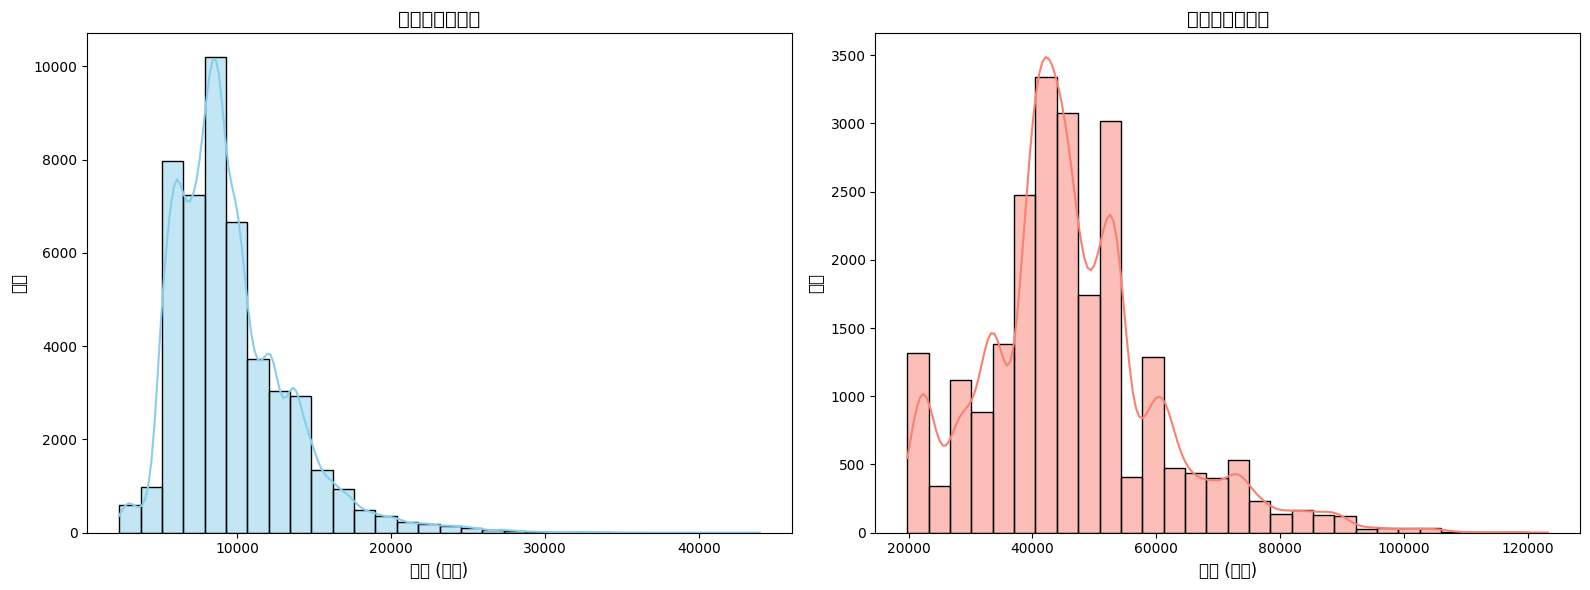

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 经济舱票价分布
sns.histplot(df_economy['Fare (Rupees)'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('经济舱票价分布', fontsize=14)
axes[0].set_xlabel('票价 (卢比)', fontsize=12)
axes[0].set_ylabel('频数', fontsize=12)

# 商务舱票价分布
sns.histplot(df_business['Fare (Rupees)'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('商务舱票价分布', fontsize=14)
axes[1].set_xlabel('票价 (卢比)', fontsize=12)
axes[1].set_ylabel('频数', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 35746 (\N{CJK UNIFIED IDEOGRAPH-8BA2}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3065172491.py:15: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from cur

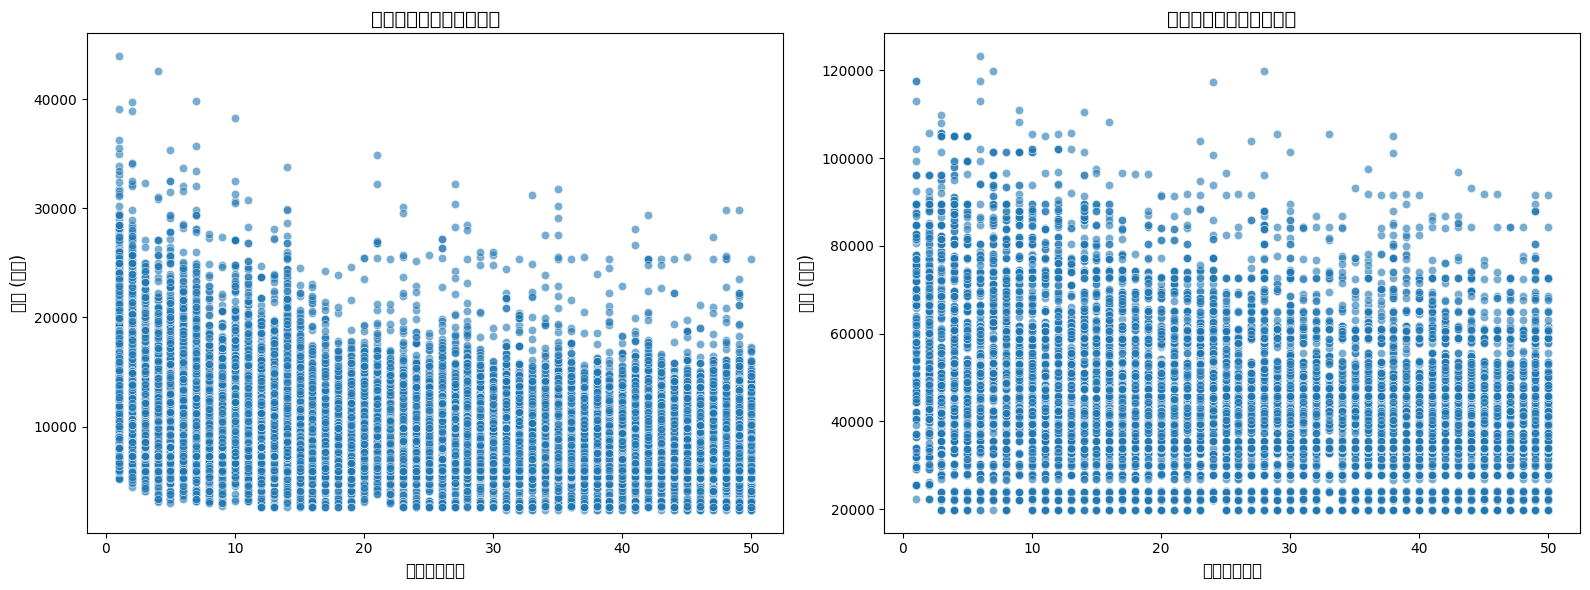

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 经济舱：提前天数 vs 票价
sns.scatterplot(data=df_economy, x='Days Before Journey Date', y='Fare (Rupees)', ax=axes[0], alpha=0.6)
axes[0].set_title('经济舱：提前天数与票价', fontsize=14)
axes[0].set_xlabel('提前预订天数', fontsize=12)
axes[0].set_ylabel('票价 (卢比)', fontsize=12)

# 商务舱：提前天数 vs 票价
sns.scatterplot(data=df_business, x='Days Before Journey Date', y='Fare (Rupees)', ax=axes[1], alpha=0.6)
axes[1].set_title('商务舱：提前天数与票价', fontsize=14)
axes[1].set_xlabel('提前预订天数', fontsize=12)
axes[1].set_ylabel('票价 (卢比)', fontsize=12)

plt.tight_layout()
plt.show()

正在拆分数据...
经济舱数据量: 47320
商务舱数据量: 23159

--- 正在训练经济舱 XGBoost 模型 ---
经济舱模型 RMSE: 2043.71 卢比
经济舱异常样本数: 474

--- 正在训练商务舱 XGBoost 模型 ---
商务舱模型 RMSE: 7041.04 卢比
商务舱异常样本数: 232

--- 分析完成 ---


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3821695262.py:119: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing fr

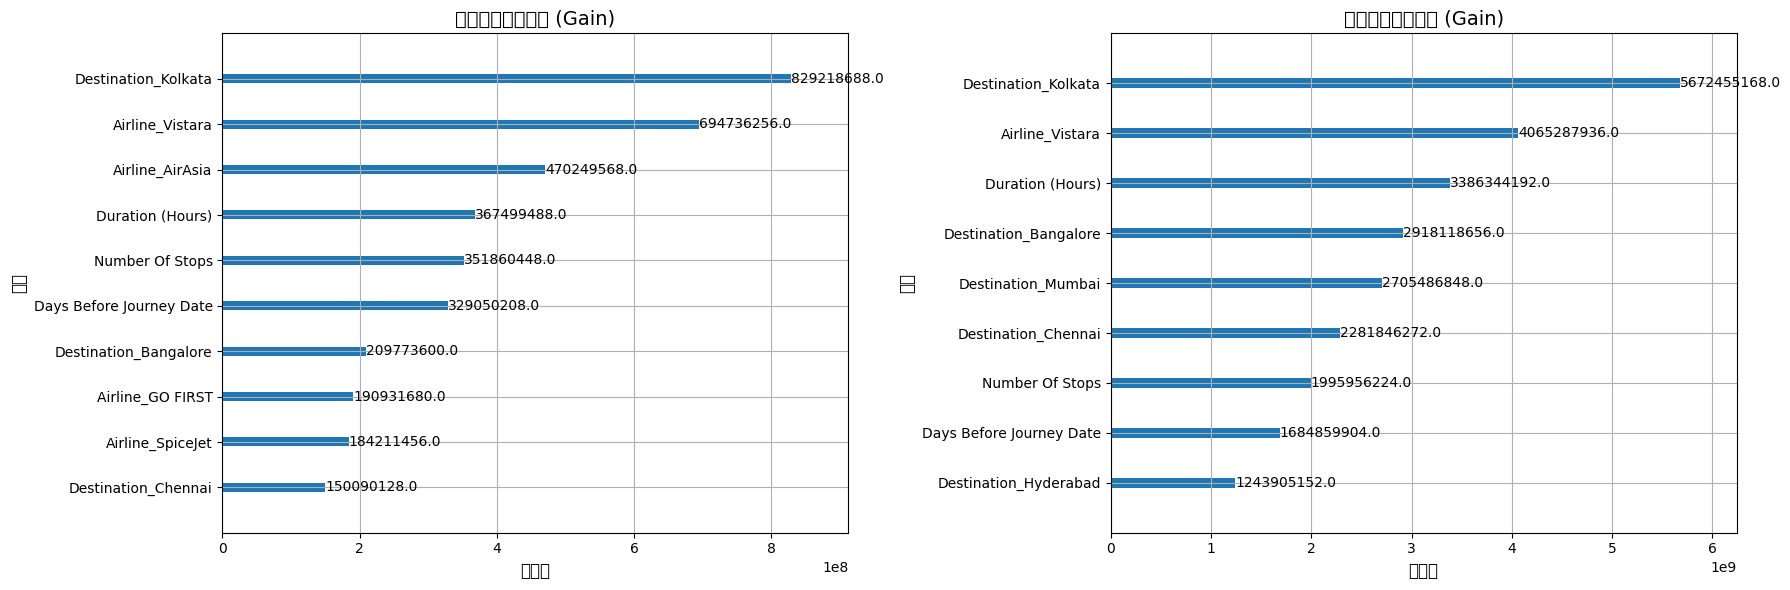


=== 经济舱最异常的 3 个样本 ===
       Actual_Price  Predicted_Price      Residual
65741         36269     16640.847656  19628.152344
17261         27134     11256.725586  15877.274414
39372         28500     12746.336914  15753.663086

=== 商务舱最异常的 3 个样本 ===
       Actual_Price  Predicted_Price      Residual
79911        110441     62324.917969  48116.082031
47738        104942     59022.082031  45919.917969
51116        109881     65666.414062  44214.585938


In [39]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==========================================
# 1. 数据拆分与特征工程
# ==========================================
print("正在拆分数据...")

# 假设 df 是你的原始完整数据集
# 先做基础特征工程 (基于原始数值列)
# 标记“最后一刻”购票
df['Is_Last_Minute'] = (df['Days Before Journey Date'] < 7).astype(int)
# 标记“早鸟”购票
df['Is_Early_Bird'] = (df['Days Before Journey Date'] > 45).astype(int)

# 拆分数据
df_economy = df[df['Class'] == 'Economy'].copy()
df_business = df[df['Class'] == 'Business'].copy()

print(f"经济舱数据量: {len(df_economy)}")
print(f"商务舱数据量: {len(df_business)}")

# 定义通用特征列
feature_cols = [
    'Days Before Journey Date',
    'Airline',
    'Destination',
    'Is_Last_Minute',
    'Is_Early_Bird',
    'Number Of Stops',
    'Duration (Hours)'
]

# ==========================================
# 2. 经济舱模型 (Economy Model)
# ==========================================
print("\n--- 正在训练经济舱 XGBoost 模型 ---")

# 准备经济舱特征
X_e = pd.get_dummies(df_economy[feature_cols], drop_first=True)
y_e = df_economy['Fare (Rupees)']

# 划分训练测试集
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

# 训练模型
model_economy = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
model_economy.fit(X_train_e, y_train_e)

# 预测与残差分析
preds_e = model_economy.predict(X_test_e)
residuals_e = y_test_e - preds_e

# 经济舱异常检测 (误差最大的前 5%)
threshold_e = np.percentile(np.abs(residuals_e), 95)
anomalies_e = X_test_e.copy()
anomalies_e['Actual_Price'] = y_test_e
anomalies_e['Predicted_Price'] = preds_e
anomalies_e['Residual'] = residuals_e
anomalies_e = anomalies_e[np.abs(anomalies_e['Residual']) > threshold_e]

print(f"经济舱模型 RMSE: {np.sqrt(np.mean(residuals_e**2)):.2f} 卢比")
print(f"经济舱异常样本数: {len(anomalies_e)}")

# ==========================================
# 3. 商务舱模型 (Business Model)
# ==========================================
print("\n--- 正在训练商务舱 XGBoost 模型 ---")

# 准备商务舱特征
X_b = pd.get_dummies(df_business[feature_cols], drop_first=True)
y_b = df_business['Fare (Rupees)']

# 划分训练测试集
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

# 训练模型
model_business = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)
model_business.fit(X_train_b, y_train_b)

# 预测与残差分析
preds_b = model_business.predict(X_test_b)
residuals_b = y_test_b - preds_b

# 商务舱异常检测 (误差最大的前 5%)
threshold_b = np.percentile(np.abs(residuals_b), 95)
anomalies_b = X_test_b.copy()
anomalies_b['Actual_Price'] = y_test_b
anomalies_b['Predicted_Price'] = preds_b
anomalies_b['Residual'] = residuals_b
anomalies_b = anomalies_b[np.abs(anomalies_b['Residual']) > threshold_b]

print(f"商务舱模型 RMSE: {np.sqrt(np.mean(residuals_b**2)):.2f} 卢比")
print(f"商务舱异常样本数: {len(anomalies_b)}")

# ==========================================
# 4. 结果对比与特征重要性可视化
# ==========================================
print("\n--- 分析完成 ---")

# 并排展示特征重要性
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 经济舱特征重要性
xgb.plot_importance(model_economy, max_num_features=10, ax=axes[0], importance_type='gain')
axes[0].set_title('经济舱特征重要性 (Gain)', fontsize=14)
axes[0].set_xlabel('重要性', fontsize=12)
axes[0].set_ylabel('特征', fontsize=12)

# 商务舱特征重要性
xgb.plot_importance(model_business, max_num_features=10, ax=axes[1], importance_type='gain')
axes[1].set_title('商务舱特征重要性 (Gain)', fontsize=14)
axes[1].set_xlabel('重要性', fontsize=12)
axes[1].set_ylabel('特征', fontsize=12)

plt.tight_layout()
plt.show()

# 打印部分异常样本
print("\n=== 经济舱最异常的 3 个样本 ===")
print(anomalies_e.sort_values('Residual', key=abs, ascending=False)[['Actual_Price', 'Predicted_Price', 'Residual']].head(3))

print("\n=== 商务舱最异常的 3 个样本 ===")
print(anomalies_b.sort_values('Residual', key=abs, ascending=False)[['Actual_Price', 'Predicted_Price', 'Residual']].head(3))

📊 经济舱 (Economy) 分析


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 35746 (\N{CJK UNIFIED IDEOGRAPH-8BA2}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\3171104984.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from cur

<Figure size 1200x600 with 0 Axes>

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31080 (\

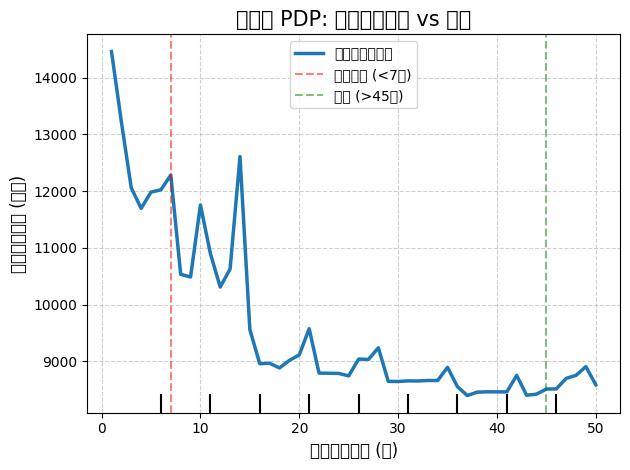

经济舱异常样本数: 474

=== 经济舱最异常的 5 个航班 ===
 Flight ID   Airline Destination  Actual_Price  Predicted_Price     Residual
     11055   AirAsia     Chennai         10548     15382.191406 -4834.191406
      5748  GO FIRST      Mumbai         24925     13467.810547 11457.189453
     35063    Indigo     Chennai         17442      9462.586914  7979.413086
     23123 Air India   Bangalore         19628     12427.064453  7200.935547
     76139  GO FIRST      Mumbai          4950     11250.588867 -6300.588867

=== 经济舱异常样本深度分析 ===
航班: 11055 (AirAsia)
实际: ₹10548, 预测: ₹15382.19140625, 误差: ₹-4834.19140625
解读: 模型高估了价格。可能是该航班有早鸟特惠或尾单甩卖。


In [40]:
# ==========================================
# 第一部分：经济舱分析
# ==========================================
print("="*30)
print("📊 经济舱 (Economy) 分析")
print("="*30)

# --- 1. 经济舱 PDP 分析 ---
plt.figure(figsize=(12, 6))
X_train_e_float = X_train_e.copy()
X_train_e_float['Days Before Journey Date'] = X_train_e_float['Days Before Journey Date'].astype(float)

PartialDependenceDisplay.from_estimator(
    model_economy, 
    X_train_e_float, 
    ['Days Before Journey Date'], 
    kind='average',
    line_kw={'label': '经济舱预测趋势', 'color': '#1f77b4', 'linewidth': 2.5}
)

plt.title('经济舱 PDP: 提前预订天数 vs 票价', fontsize=15)
plt.xlabel('提前预订天数 (天)', fontsize=12)
plt.ylabel('预测平均票价 (卢比)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='最后一刻 (<7天)')
plt.axvline(x=45, color='green', linestyle='--', alpha=0.5, label='早鸟 (>45天)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. 经济舱异常检测与归因 ---
# 预测与残差计算
preds_e = model_economy.predict(X_test_e)
residuals_e = y_test_e - preds_e

# 整合结果
df_test_e = X_test_e.copy()
df_test_e['Actual_Price'] = y_test_e
df_test_e['Predicted_Price'] = preds_e
df_test_e['Residual'] = residuals_e
df_test_e['Abs_Residual'] = np.abs(residuals_e)

# 找出异常值 (前 5%)
threshold_e = np.percentile(df_test_e['Abs_Residual'], 95)
anomalies_e = df_test_e[df_test_e['Abs_Residual'] > threshold_e]

# 合并原始信息以便展示
anomaly_details_e = pd.merge(
    anomalies_e, 
    df_economy[['Airline', 'Destination', 'Flight ID']].loc[anomalies_e.index], 
    left_index=True, right_index=True
)

print(f"经济舱异常样本数: {len(anomalies_e)}")
print("\n=== 经济舱最异常的 5 个航班 ===")
print(anomaly_details_e[['Flight ID', 'Airline', 'Destination', 'Actual_Price', 'Predicted_Price', 'Residual']].head().to_string(index=False))

# 业务解读
if len(anomalies_e) > 0:
    sample_e = anomalies_e.iloc[0]
    print(f"\n=== 经济舱异常样本深度分析 ===")
    print(f"航班: {anomaly_details_e.iloc[0]['Flight ID']} ({anomaly_details_e.iloc[0]['Airline']})")
    print(f"实际: ₹{sample_e['Actual_Price']}, 预测: ₹{sample_e['Predicted_Price']}, 误差: ₹{sample_e['Residual']}")
    if sample_e['Residual'] > 0:
        print("解读: 模型低估了价格。可能是该航班在特定日期（如节假日）有临时溢价，或者是廉价航空的行李附加费未被模型捕捉。")
    else:
        print("解读: 模型高估了价格。可能是该航班有早鸟特惠或尾单甩卖。")


    


💎 商务舱 (Business) 分析


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 35746 (\N{CJK UNIFIED IDEOGRAPH-8BA2}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from current font.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_4204\756255433.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current f

<Figure size 1200x600 with 0 Axes>

C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31080 (\

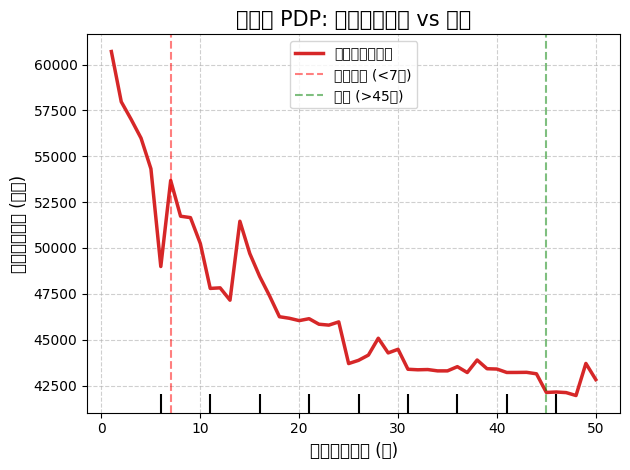

商务舱异常样本数: 232

=== 商务舱最异常的 5 个航班 ===
 Flight ID   Airline Destination  Actual_Price  Predicted_Price     Residual
     50303   Vistara   Hyderabad         74086     52695.335938 21390.664062
     32583   Vistara     Kolkata         59336     36949.101562 22386.898438
     78696   Vistara      Mumbai         82010     59705.671875 22304.328125
     79046   Vistara      Mumbai         85096     57726.691406 27369.308594
     48937 Air India      Mumbai         73701     54238.453125 19462.546875

=== 商务舱异常样本深度分析 ===
航班: 50303 (Vistara)
实际: ₹74086, 预测: ₹52695.3359375, 误差: ₹21390.6640625
解读: 模型低估了价格。这通常是因为商务舱的全价票（Fully Flexible）在临近出发时价格飙升，或者该航班由宽体机执飞（如 B787），服务溢价高。


In [41]:
# ==========================================
# 第二部分：商务舱分析
# ==========================================
print("\n" + "="*30)
print("💎 商务舱 (Business) 分析")
print("="*30)

# --- 1. 商务舱 PDP 分析 ---
plt.figure(figsize=(12, 6))
X_train_b_float = X_train_b.copy()
X_train_b_float['Days Before Journey Date'] = X_train_b_float['Days Before Journey Date'].astype(float)

PartialDependenceDisplay.from_estimator(
    model_business, 
    X_train_b_float, 
    ['Days Before Journey Date'], 
    kind='average',
    line_kw={'label': '商务舱预测趋势', 'color': '#d62728', 'linewidth': 2.5}
)

plt.title('商务舱 PDP: 提前预订天数 vs 票价', fontsize=15)
plt.xlabel('提前预订天数 (天)', fontsize=12)
plt.ylabel('预测平均票价 (卢比)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=7, color='red', linestyle='--', alpha=0.5, label='最后一刻 (<7天)')
plt.axvline(x=45, color='green', linestyle='--', alpha=0.5, label='早鸟 (>45天)')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. 商务舱异常检测与归因 ---
# 预测与残差计算
preds_b = model_business.predict(X_test_b)
residuals_b = y_test_b - preds_b

# 整合结果
df_test_b = X_test_b.copy()
df_test_b['Actual_Price'] = y_test_b
df_test_b['Predicted_Price'] = preds_b
df_test_b['Residual'] = residuals_b
df_test_b['Abs_Residual'] = np.abs(residuals_b)

# 找出异常值 (前 5%)
threshold_b = np.percentile(df_test_b['Abs_Residual'], 95)
anomalies_b = df_test_b[df_test_b['Abs_Residual'] > threshold_b]

# 合并原始信息
anomaly_details_b = pd.merge(
    anomalies_b, 
    df_business[['Airline', 'Destination', 'Flight ID']].loc[anomalies_b.index], 
    left_index=True, right_index=True
)

print(f"商务舱异常样本数: {len(anomalies_b)}")
print("\n=== 商务舱最异常的 5 个航班 ===")
print(anomaly_details_b[['Flight ID', 'Airline', 'Destination', 'Actual_Price', 'Predicted_Price', 'Residual']].head().to_string(index=False))

# 业务解读
if len(anomalies_b) > 0:
    sample_b = anomalies_b.iloc[0]
    print(f"\n=== 商务舱异常样本深度分析 ===")
    print(f"航班: {anomaly_details_b.iloc[0]['Flight ID']} ({anomaly_details_b.iloc[0]['Airline']})")
    print(f"实际: ₹{sample_b['Actual_Price']}, 预测: ₹{sample_b['Predicted_Price']}, 误差: ₹{sample_b['Residual']}")
    if sample_b['Residual'] > 0:
        print("解读: 模型低估了价格。这通常是因为商务舱的全价票（Fully Flexible）在临近出发时价格飙升，或者该航班由宽体机执飞（如 B787），服务溢价高。")
    else:
        print("解读: 模型高估了价格。可能是商务舱出现了罕见的折扣（如里程兑换升舱后的余票销售），或者是企业协议价。")

In [42]:
def predict_fare(row, model_economy, model_business, feature_cols):
    """
    根据舱位自动选择模型进行预测
    """
    # 1. 准备特征 (注意：需要像训练时一样做 One-Hot 处理，这里假设你有一个预处理函数)
    # 实际使用中，建议用 sklearn 的 ColumnTransformer 或 Pipeline 来处理
    X_input = pd.DataFrame([row]) # 将单行数据转为 DataFrame
    
    # 简单的 One-Hot 模拟 (实际项目中请确保与训练集特征对齐)
    X_processed = pd.get_dummies(X_input[feature_cols], drop_first=True)
    
    # 确保缺失的列补0 (防止新数据中某些类别没出现过导致报错)
    # 这里为了演示简化，假设特征已经对齐
    
    # 2. 路由逻辑
    if row['Class'] == 'Economy':
        pred = model_economy.predict(X_processed)[0]
        model_used = "经济舱模型"
    elif row['Class'] == 'Business':
        pred = model_business.predict(X_processed)[0]
        model_used = "商务舱模型"
    else:
        # 兜底策略：如果舱位未知，可以返回平均值或报错
        pred = None 
        model_used = "未知"
        
    return pred, model_used

# --- 测试预测 ---
# 假设这是两条新数据
new_data_1 = {
    'Class': 'Economy', 
    'Days Before Journey Date': 10, 
    'Airline': 'Vistara', 
    'Destination': 'Bangalore',
    'Is_Last_Minute': 0,
    'Is_Early_Bird': 0,
    'Number Of Stops': 0,
    'Duration (Hours)': 2.5
}

new_data_2 = {
    'Class': 'Business', 
    'Days Before Journey Date': 2, 
    'Airline': 'Air India', 
    'Destination': 'London',
    'Is_Last_Minute': 1,
    'Is_Early_Bird': 0,
    'Number Of Stops': 1,
    'Duration (Hours)': 8.0
}

# 执行预测
price_1, used_1 = predict_fare(new_data_1, model_economy, model_business, feature_cols)
price_2, used_2 = predict_fare(new_data_2, model_economy, model_business, feature_cols)

print(f"数据1预测结果: ₹{price_1:.2f} (使用: {used_1})")
print(f"数据2预测结果: ₹{price_2:.2f} (使用: {used_2})")

ValueError: feature_names mismatch: ['Days Before Journey Date', 'Is_Last_Minute', 'Is_Early_Bird', 'Number Of Stops', 'Duration (Hours)', 'Airline_AirAsia', 'Airline_AkasaAir', 'Airline_AllianceAir', 'Airline_GO FIRST', 'Airline_Indigo', 'Airline_SpiceJet', 'Airline_Vistara', 'Destination_Bangalore', 'Destination_Chennai', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_Mumbai'] ['Days Before Journey Date', 'Is_Last_Minute', 'Is_Early_Bird', 'Number Of Stops', 'Duration (Hours)']
expected Airline_Indigo, Airline_AllianceAir, Destination_Chennai, Destination_Hyderabad, Airline_AkasaAir, Destination_Mumbai, Airline_SpiceJet, Airline_AirAsia, Destination_Kolkata, Airline_GO FIRST, Destination_Bangalore, Airline_Vistara in input data

In [23]:
# 逻辑型异常检测 (Business Rule Check)
# 检查：提前0-7天买的票，是否比提前30-60天买的票便宜？
# 这通常不符合供需规律，可能是数据录入错误或特殊促销。

def check_price_vs_days(row):
    # 假设提前天数少于7天是 Last Minute
    if row['Days Before Journey Date'] < 7:
        # 获取该航线的历史平均价格（排除最后一周）
        historical_avg = df[(df['Route'] == row['Route']) & 
                           (df['Days Before Journey Date'] > 7)]['Fare (Rupees)'].mean()
        # 如果最后一周的价格显著低于历史均价，标记为可疑
        if historical_avg > 0 and row['Fare (Rupees)'] < historical_avg * 0.5:
            return 'Suspicious_Low'
    return 'Normal'

# df['Price_Quality_Flag'] = df.apply(check_price_vs_days, axis=1)